In [15]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import src.utils as utils

utils = importlib.reload(utils)

from pyspark.sql import functions as F

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h1>Notebook EDA de MovieLens</h1>

<h2>Sélection de la source</h2>

Modifier uniquement la constante `DATA_SOURCE` dans la cellule suivante.

Sources autorisées dans ce notebook :
- `raw_small` -> `data/raw_small` (CSV)
- `raw_big` -> `data/raw_big` (CSV)

Exemple :
- `DATA_SOURCE = "raw_small"`

Note importante :
- Ce notebook EDA lit les donnees brutes (`raw_*`), puis applique le nettoyage en memoire.
- Les analyses (baseline, split, tendances) sont faites sur les donnees nettoyees.
- Les artefacts nettoyes/splittes sont ensuite sauvegardes dans `data/processed/*` pour le notebook de modelisation.
- `links.csv` est charge uniquement pour les sources CSV (`raw_*`).

</div>

In [16]:
DATA_SOURCE = "raw_small"

PROJECT_ROOT = utils.get_project_root()

dataset_format, path_ratings, path_movies = utils.resolve_data_source_paths(
    DATA_SOURCE, project_root=PROJECT_ROOT
)

print(f"Racine projet: {PROJECT_ROOT}")
print(f"Source: {DATA_SOURCE}")
print(f"Format: {dataset_format}")
print(f"ratings: {path_ratings}")
print(f"movies: {path_movies}")

Racine projet: /home/coule/Desktop/Documents/projets/sparkle-movie
Source: raw_small
Format: csv
ratings: /home/coule/Desktop/Documents/projets/sparkle-movie/data/raw_small/ratings.csv
movies: /home/coule/Desktop/Documents/projets/sparkle-movie/data/raw_small/movies.csv


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Chargement des datasets

In [17]:
# Initialisation de la sessionSpark et chargement de la source sélectionnée
spark = utils.create_spark_session()

# Réduction du niveau de log pour éviter les messages d'avertissement et d'information
# qui peuvent être nombreux lors du chargement et du traitement des données
# Seuls les messages d'erreur seront affichés.
spark.sparkContext.setLogLevel("ERROR")

# Chargement des CSV  Path.as_posix() → convertit un chemin en chaîne de caractères avec des / (format POSIX)
df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())

# La vérification préalable évite des analyses incohérentes si le fichier attendu est absent.
path_links = path_ratings.parent / "links.csv"
if not path_links.exists():
    raise FileNotFoundError(f"Fichier links.csv introuvable: {path_links}")
df_links = utils.load_links_dataframe(spark, path_links.as_posix())

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Ratings : aperçu de la structure et des 10 premières lignes

In [18]:
print("--- ratings : Schema ---")
df_ratings.printSchema()
print("--- ratings : 10 premières lignes ---")
df_ratings.show(10, truncate=False)


--- ratings : Schema ---
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

--- ratings : 10 premières lignes ---
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
|1     |70     |3.0   |964982400|
|1     |101    |5.0   |964980868|
|1     |110    |4.0   |964982176|
|1     |151    |5.0   |964984041|
|1     |157    |5.0   |964984100|
+------+-------+------+---------+
only showing top 10 rows



<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
movies : aperçu de la structure et des 10 premières lignes

In [19]:
print("--- movies : Schema ---")
df_movies.printSchema()
print("--- movies : 10 premières lignes ---")
df_movies.show(10, truncate=False)

--- movies : Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--- movies : 10 premières lignes ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
|6      |Heat (1995)                       |Action|Crime|Thriller                      |
|7      |Sabrina 

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Links : aperçu de la structure et des 10 premières lignes

In [20]:
if df_links is not None:
    print("--- links : Schema ---")
    df_links.printSchema()
    print("--- links : 10 premières lignes ---")
    df_links.show(10, truncate=False)

--- links : Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- imdbId: integer (nullable = true)
 |-- tmdbId: integer (nullable = true)

--- links : 10 premières lignes ---
+-------+------+------+
|movieId|imdbId|tmdbId|
+-------+------+------+
|1      |114709|862   |
|2      |113497|8844  |
|3      |113228|15602 |
|4      |114885|31357 |
|5      |113041|11862 |
|6      |113277|949   |
|7      |114319|11860 |
|8      |112302|45325 |
|9      |114576|9091  |
|10     |113189|710   |
+-------+------+------+
only showing top 10 rows



<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Nettoyage des donnees</h2>
On applique `clean_data` pour retirer les valeurs manquantes critiques et les doublons.
</div>

In [21]:
# Nettoyage des DataFrames
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

print("Lignes ratings avant/apres:", df_ratings.count(), "/", df_ratings_clean.count())
print("Lignes movies avant/apres:", df_movies.count(), "/", df_movies_clean.count())

Lignes ratings avant/apres: 100836 / 100836
Lignes movies avant/apres: 9742 / 9742


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Baseline orientée recommandation</h2>

Cette section sert a verifier si les donnees sont adaptees a un systeme de recommandation personnalisee.

Calcul :

- tailles du dataset

- densite user-item

- distributions d'interactions

- taux d'utilisateurs/items rares.
</div>

--- Baseline recommandations ---
Utilisateurs uniques : 610
Films uniques : 9724
Interactions (ratings) : 100836
Densite user-item : 0.017000

--- Activite utilisateurs (resume) ---
+-------+------------------+
|summary|n_ratings_user    |
+-------+------------------+
|count  |610               |
|min    |20                |
|25%    |35                |
|50%    |70                |
|75%    |168               |
|max    |2698              |
|mean   |165.30491803278687|
+-------+------------------+

--- Activite films (resume) ---
+-------+------------------+
|summary|n_ratings_item    |
+-------+------------------+
|count  |9724              |
|min    |1                 |
|25%    |1                 |
|50%    |3                 |
|75%    |9                 |
|max    |329               |
|mean   |10.369806663924312|
+-------+------------------+

Utilisateurs rares (< 5 notes): 0 (0.00%)
Films rares (< 5 notes): 6074 (62.46%)


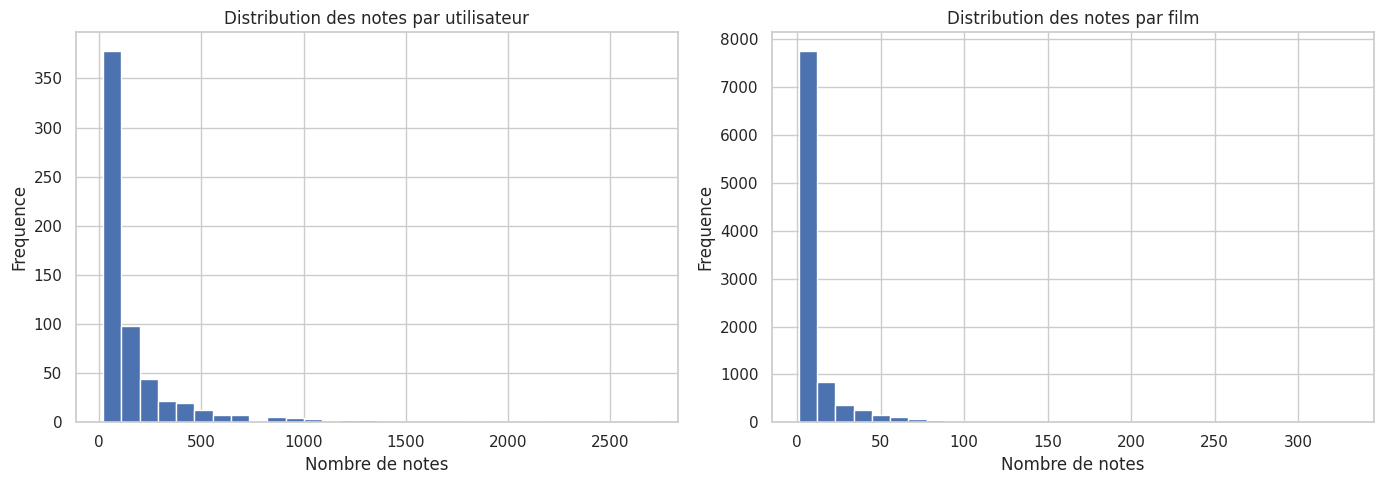

In [22]:
# Cellule autonome: on recree une session Spark et on recharge les donnees propres.
spark = utils.create_spark_session()
df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

# Statistiques globales
n_users = df_ratings_clean.select("userId").distinct().count()
n_movies = df_ratings_clean.select("movieId").distinct().count()
n_interactions = df_ratings_clean.count()

density = n_interactions / (n_users * n_movies) if n_users and n_movies else 0.0

print("--- Baseline recommandations ---")
print(f"Utilisateurs uniques : {n_users}")
print(f"Films uniques : {n_movies}")
print(f"Interactions (ratings) : {n_interactions}")
print(f"Densite user-item : {density:.6f}")

# Distribution du nombre de notes par utilisateur
df_user_activity = (
    df_ratings_clean.groupBy("userId")
    .agg(F.count("*").alias("n_ratings_user"))
)

# Distribution du nombre de notes par film
df_item_activity = (
    df_ratings_clean.groupBy("movieId")
    .agg(F.count("*").alias("n_ratings_item"))
)

print("\n--- Activite utilisateurs (resume) ---")
df_user_activity.select("n_ratings_user").summary("count", "min", "25%", "50%", "75%", "max", "mean").show(truncate=False)

print("--- Activite films (resume) ---")
df_item_activity.select("n_ratings_item").summary("count", "min", "25%", "50%", "75%", "max", "mean").show(truncate=False)

# Taux d'utilisateurs/items rares
min_interactions = 5
rare_users = df_user_activity.filter(F.col("n_ratings_user") < min_interactions).count()
rare_items = df_item_activity.filter(F.col("n_ratings_item") < min_interactions).count()

rare_users_rate = rare_users / n_users if n_users else 0.0
rare_items_rate = rare_items / n_movies if n_movies else 0.0

print(f"Utilisateurs rares (< {min_interactions} notes): {rare_users} ({rare_users_rate:.2%})")
print(f"Films rares (< {min_interactions} notes): {rare_items} ({rare_items_rate:.2%})")

# Histogrammes (conversion pandas limitee pour visualisation)
import matplotlib.pyplot as plt

pdf_user = df_user_activity.select("n_ratings_user").toPandas()
pdf_item = df_item_activity.select("n_ratings_item").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pdf_user["n_ratings_user"], bins=30)
axes[0].set_title("Distribution des notes par utilisateur")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("Frequence")

axes[1].hist(pdf_item["n_ratings_item"], bins=30)
axes[1].set_title("Distribution des notes par film")
axes[1].set_xlabel("Nombre de notes")
axes[1].set_ylabel("Frequence")

plt.tight_layout()
plt.show()

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h3>resultats pour DATA_SOURCE = "raw_small"</h3>

- Utilisateurs uniques: 610
- Films uniques: 9724
- Interactions: 100836
- Densite user-item: 0.017000

Interpretation:
- La densite est faible (matrice creuse), ce qui est normal en recommandation.
- Les modeles collaboratifs (ALS, KNN user-user) devront gerer la rarete des interactions.

Sparsity / rarete:
- Utilisateurs rares (< 5 notes): 0 (0.00%)
- Films rares (< 5 notes): 6074 (62.46%)

Interpretation:
- Il y a tres peu d'utilisateurs froids dans ce jeu small.
- En revanche, beaucoup de films ont peu de notes (longue traine), ce qui peut fragiliser les recommandations sur ces items.

Visualisation:
- Les histogrammes montrent la distribution du nombre de notes par utilisateur et par film.
- Cette etape aide a choisir des seuils minimaux d'interactions avant modelisation.

</div>

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Split temporel anti-fuite</h2>

Le split temporel separe les interactions selon leur date (timestamp).<br>
Ancien pour entraînement, plus récent pour validation, plus récent encore pour test.

En production, on predit toujours le futur a partir du passe<br>
Le split temporel reproduit ce scenario reel, contrairement a un split aleatoire qui melange passe et futur<br>
Il limite la fuite de donnees (data leakage): le modele n'apprend pas sur des evenements qui se produisent apres ceux qu'il doit predire.
</div>

In [23]:
# Split temporel global: 80% train, 10% validation, 10% test
quantiles = df_ratings_clean.approxQuantile("timestamp", [0.8, 0.9], 0.0)
t80, t90 = quantiles

df_train = df_ratings_clean.filter(F.col("timestamp") <= t80)
df_val = df_ratings_clean.filter((F.col("timestamp") > t80) & (F.col("timestamp") <= t90))
df_test = df_ratings_clean.filter(F.col("timestamp") > t90)

n_train = df_train.count()
n_val = df_val.count()
n_test = df_test.count()
n_total = n_train + n_val + n_test

print("--- Split temporel anti-fuite ---")
print(f"Seuil t80: {t80} | Seuil t90: {t90}")
print(f"Train: {n_train} ({n_train / n_total:.2%})")
print(f"Validation: {n_val} ({n_val / n_total:.2%})")
print(f"Test: {n_test} ({n_test / n_total:.2%})")

# Verification rapide des recouvrements de periodes
min_train_ts, max_train_ts = df_train.select(F.min("timestamp"), F.max("timestamp")).first()
min_val_ts, max_val_ts = df_val.select(F.min("timestamp"), F.max("timestamp")).first()
min_test_ts, max_test_ts = df_test.select(F.min("timestamp"), F.max("timestamp")).first()

print("\nPeriodes par split:")
print(f"Train:      [{min_train_ts}, {max_train_ts}]")
print(f"Validation: [{min_val_ts}, {max_val_ts}]")
print(f"Test:       [{min_test_ts}, {max_test_ts}]")

# Optionnel: persistance pour le notebook 2
save_splits = False
if save_splits:
    split_root = PROJECT_ROOT / "data" / "processed" / "small" / "splits_temporal"
    (df_train.write.mode("overwrite").parquet((split_root / "train").as_posix()))
    (df_val.write.mode("overwrite").parquet((split_root / "validation").as_posix()))
    (df_test.write.mode("overwrite").parquet((split_root / "test").as_posix()))
    print(f"Splits sauvegardes dans: {split_root}")

--- Split temporel anti-fuite ---
Seuil t80: 1458635171.0 | Seuil t90: 1498029450.0
Train: 80669 (80.00%)
Validation: 10084 (10.00%)
Test: 10083 (10.00%)

Periodes par split:
Train:      [828124615, 1458635171]
Validation: [1458635237, 1498029450]
Test:       [1498029469, 1537799250]


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h3>Résultats DATA_SOURCE = "raw_small" :</h3>

- Train: 80669 (80.00%)
- Validation: 10084 (10.00%)
- Test: 10083 (10.00%)
- Les periodes sont non chevauchantes, donc l'evaluation est plus fiable.

A faire:
- Garder ce protocole pour comparer ALS, contenu et KNN sur la meme base d'evaluation.

</div>

In [24]:
# Configuration reproductibilite
RANDOM_SEED = 42  # utile pour les etapes aleatoires du notebook 2
SAVE_ARTIFACTS = True

if DATA_SOURCE != "raw_small":
    print(f"Attention: cette cellule cible principalement raw_small. Source actuelle: {DATA_SOURCE}")

# Cellule autonome: on recree la session et on recalcule les jeux propres/splits
spark = utils.create_spark_session()
df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

quantiles = df_ratings_clean.approxQuantile("timestamp", [0.8, 0.9], 0.0)
t80, t90 = quantiles
df_train = df_ratings_clean.filter(F.col("timestamp") <= t80)
df_val = df_ratings_clean.filter((F.col("timestamp") > t80) & (F.col("timestamp") <= t90))
df_test = df_ratings_clean.filter(F.col("timestamp") > t90)

output_root = PROJECT_ROOT / "data" / "processed" / "small"
path_ratings_clean = output_root / "ratings_clean.parquet"
path_movies_clean = output_root / "movies_clean.parquet"
path_split_root = output_root / "splits_temporal"

if SAVE_ARTIFACTS:
    df_ratings_clean.write.mode("overwrite").parquet(path_ratings_clean.as_posix())
    df_movies_clean.write.mode("overwrite").parquet(path_movies_clean.as_posix())
    df_train.write.mode("overwrite").parquet((path_split_root / "train").as_posix())
    df_val.write.mode("overwrite").parquet((path_split_root / "validation").as_posix())
    df_test.write.mode("overwrite").parquet((path_split_root / "test").as_posix())

    print("--- Artefacts sauvegardes ---")
    print(f"ratings_clean: {path_ratings_clean}")
    print(f"movies_clean: {path_movies_clean}")
    print(f"splits: {path_split_root}")
    print(f"RANDOM_SEED configuree: {RANDOM_SEED}")
else:
    print("SAVE_ARTIFACTS=False: aucun fichier ecrit.")

--- Artefacts sauvegardes ---
ratings_clean: /home/coule/Desktop/Documents/projets/sparkle-movie/data/processed/small/ratings_clean.parquet
movies_clean: /home/coule/Desktop/Documents/projets/sparkle-movie/data/processed/small/movies_clean.parquet
splits: /home/coule/Desktop/Documents/projets/sparkle-movie/data/processed/small/splits_temporal
RANDOM_SEED configuree: 42


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Sauvegarde des artefacts (small)</h2>
Cette section enregistre les datasets nettoyes et les splits temporels pour reutilisation dans le notebook de modelisation.

Note: la seed est preparee pour les etapes aleatoires futures (ALS, randomSplit, echantillonnage).
</div>

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Tendances generales</h2>
Calcule le top des films par note moyenne (avec seuil minimal de votes) et les genres les plus populaires.

In [25]:
# Top films et genres populaires
df_top_movies = utils.top_rated_movies(df_ratings_clean, df_movies_clean)
df_top_genres = utils.most_popular_genres(df_ratings_clean, df_movies_clean)

print("--- Top 10 films les mieux notes (min 50 votes) ---")
df_top_movies.show(10, truncate=False)

print("--- Top 10 genres les plus populaires ---")
df_top_genres.show(10, truncate=False)

--- Top 10 films les mieux notes (min 50 votes) ---
+-------+---------------------------------------------------------------------------+-----------------+---------+
|movieId|title                                                                      |avg_rating       |n_ratings|
+-------+---------------------------------------------------------------------------+-----------------+---------+
|318    |Shawshank Redemption, The (1994)                                           |4.429022082018927|317      |
|858    |Godfather, The (1972)                                                      |4.2890625        |192      |
|2959   |Fight Club (1999)                                                          |4.272935779816514|218      |
|1276   |Cool Hand Luke (1967)                                                      |4.271929824561403|57       |
|750    |Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)|4.268041237113402|97       |
|904    |Rear Window (1954)         

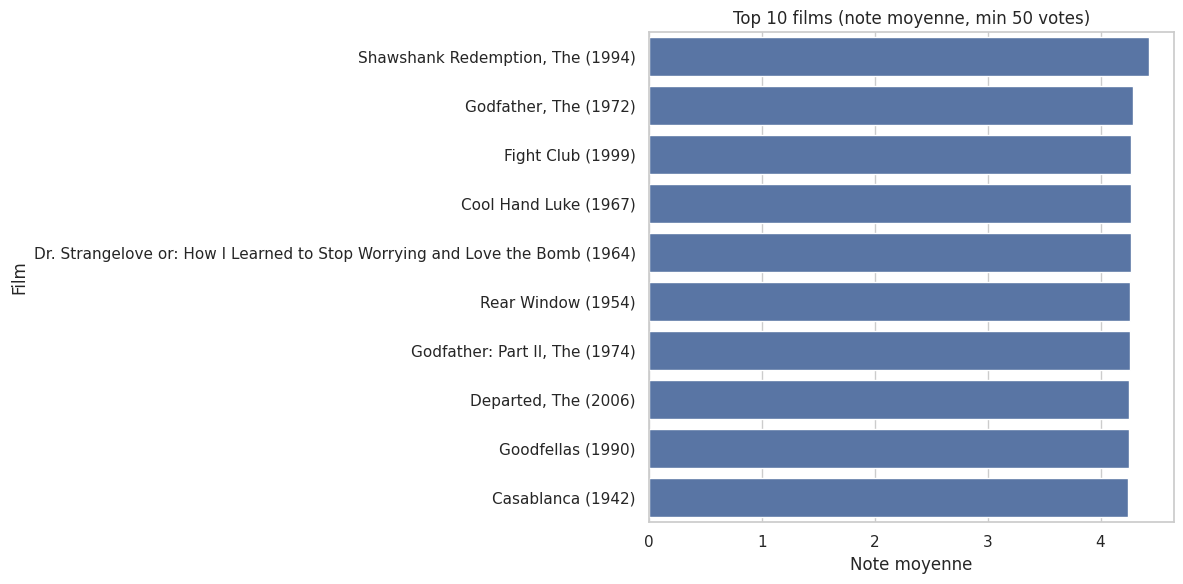

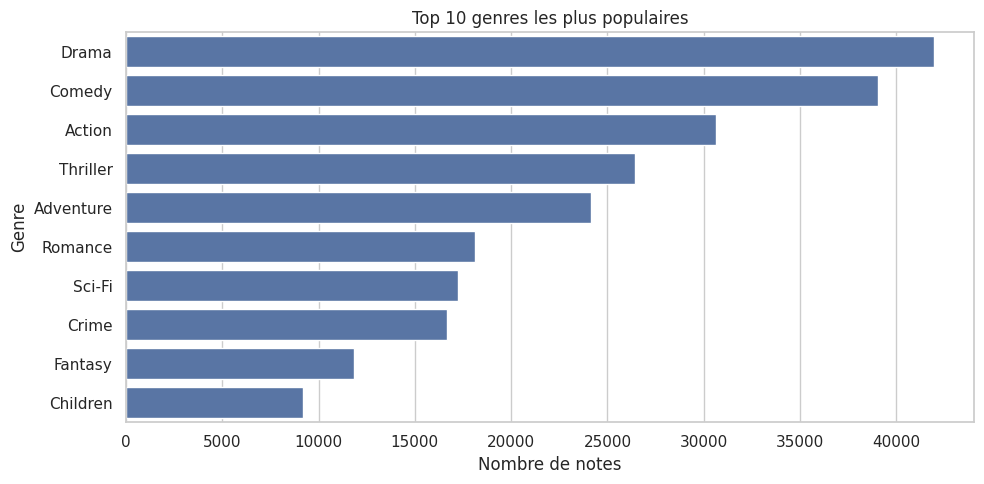

In [26]:
# Visualisations
utils.plot_results(df_top_movies, df_top_genres)

In [27]:
# Libération propre de la session Spark
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.
